# Chess Opening Prediction: Does Opening Theory Predict Match Outcomes?
### ITCS 3156 Final Project
## Sai Khushal Dulam

## Imports


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import shap
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('games.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (20058, 16)


,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5


## 3. Exploratory Data Analysis


In [5]:
# Basic info
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              20058 non-null  object 
 1   rated           20058 non-null  bool   
 2   created_at      20058 non-null  float64
 3   last_move_at    20058 non-null  float64
 4   turns           20058 non-null  int64  
 5   victory_status  20058 non-null  object 
 6   winner          20058 non-null  object 
 7   increment_code  20058 non-null  object 
 8   white_id        20058 non-null  object 
 9   white_rating    20058 non-null  int64  
 10  black_id        20058 non-null  object 
 11  black_rating    20058 non-null  int64  
 12  moves           20058 non-null  object 
 13  opening_eco     20058 non-null  object 
 14  opening_name    20058 non-null  object 
 15  opening_ply     20058 non-null  int64  
dtypes: bool(1), float64(2), int64(4), object(9)
memory usage: 2.3+ MB
None

Miss

winner
white    10001
black     9107
draw       950
Name: count, dtype: int64


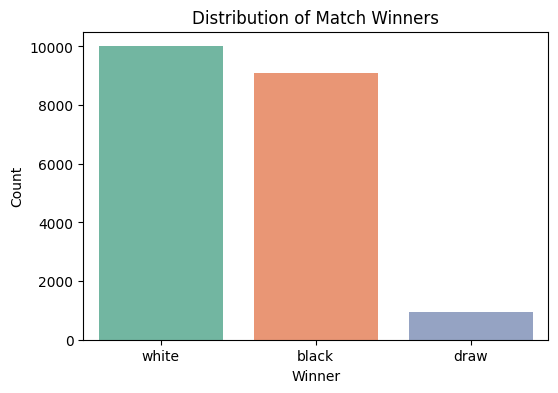

In [6]:
# Class distribution - who wins?
print(df['winner'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='winner', palette='Set2')
plt.title('Distribution of Match Winners')
plt.xlabel('Winner')
plt.ylabel('Count')
plt.show()

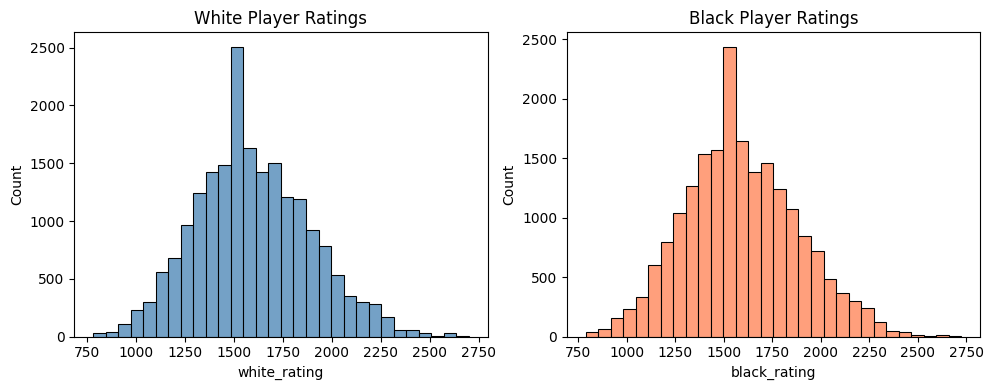

In [7]:
# Rating distributions
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df['white_rating'], bins=30, color='steelblue')
plt.title('White Player Ratings')

plt.subplot(1,2,2)
sns.histplot(df['black_rating'], bins=30, color='coral')
plt.title('Black Player Ratings')
plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [8]:
# Rating difference (main predictor)
df['rating_diff'] = df['white_rating'] - df['black_rating']

# Parse time control into category
def classify_time_control(code):
    try:
        base = int(code.split('+')[0])
        if base < 3:
            return 'bullet'
        elif base < 10:
            return 'blitz'
        elif base < 30:
            return 'rapid'
        else:
            return 'classical'
    except:
        return 'unknown'

df['time_control'] = df['increment_code'].apply(classify_time_control)

# Opening family from ECO code (first letter)
df['opening_family'] = df['opening_eco'].str[0]

# Rated as integer
df['rated_int'] = df['rated'].astype(int)

print(df[['rating_diff', 'time_control', 'opening_family', 'rated_int']].head(10))

   rating_diff time_control opening_family  rated_int
0          309        rapid              D          0
1           61        blitz              B          1
2           -4        blitz              C          1
3          -15        rapid              D          1
4           54    classical              C          1
5          248        rapid              B          0
6           97        rapid              D          1
7         -695        rapid              B          0
8           47        rapid              C          1
9          172        rapid              B          1


In [9]:
# Check distributions of new features
print(df['time_control'].value_counts())
print()
print(df['opening_family'].value_counts())

time_control
rapid        14709
blitz         3939
classical     1279
bullet         131
Name: count, dtype: int64

opening_family
C    7658
B    5238
A    3973
D    2683
E     506
Name: count, dtype: int64


## 5. Preprocessing & Model Preparation

In [10]:
# Drop draws, focus on binary classification first
df_model = df[df['winner'] != 'draw'].copy()
df_model['target'] = (df_model['winner'] == 'white').astype(int)

# Features
features = ['rating_diff', 'opening_ply', 'rated_int', 'turns']
df_encoded = pd.get_dummies(df_model[features + ['time_control', 'opening_family']])

X = df_encoded
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Features: {X_train.shape[1]}")

Training samples: 15286
Test samples: 3822
Features: 13


## 6. Model 1 - Logistic Regression (Baseline)

In [11]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("=== Logistic Regression Results ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=['Black Wins', 'White Wins']))

=== Logistic Regression Results ===
Accuracy: 0.6538

              precision    recall  f1-score   support

  Black Wins       0.65      0.60      0.62      1832
  White Wins       0.66      0.71      0.68      1990

    accuracy                           0.65      3822
   macro avg       0.65      0.65      0.65      3822
weighted avg       0.65      0.65      0.65      3822



## 7. Model 2 - XGBoost

In [12]:
xgb = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                     random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("=== XGBoost Results ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print()
print(classification_report(y_test, y_pred_xgb, target_names=['Black Wins', 'White Wins']))

=== XGBoost Results ===
Accuracy: 0.8456

              precision    recall  f1-score   support

  Black Wins       0.83      0.85      0.84      1832
  White Wins       0.86      0.84      0.85      1990

    accuracy                           0.85      3822
   macro avg       0.85      0.85      0.85      3822
weighted avg       0.85      0.85      0.85      3822



## 8. Model 3 - Random Forest

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Random Forest Results ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=['Black Wins', 'White Wins']))

=== Random Forest Results ===
Accuracy: 0.6693

              precision    recall  f1-score   support

  Black Wins       0.66      0.63      0.64      1832
  White Wins       0.67      0.71      0.69      1990

    accuracy                           0.67      3822
   macro avg       0.67      0.67      0.67      3822
weighted avg       0.67      0.67      0.67      3822



## 9. Model Comparison

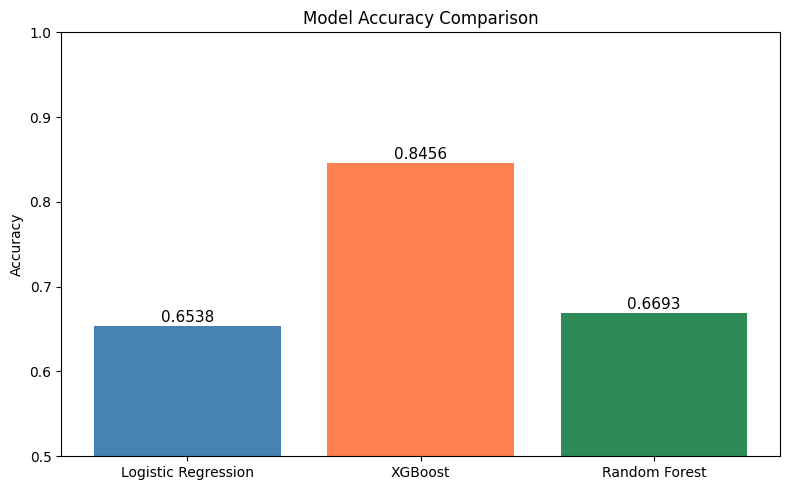

In [14]:
# Accuracy comparison bar chart
models = ['Logistic Regression', 'XGBoost', 'Random Forest']
accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_xgb),
    accuracy_score(y_test, y_pred_rf)
]

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracies, color=['steelblue', 'coral', 'seagreen'])
plt.ylim(0.5, 1.0)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.4f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

## Confusion Matrices

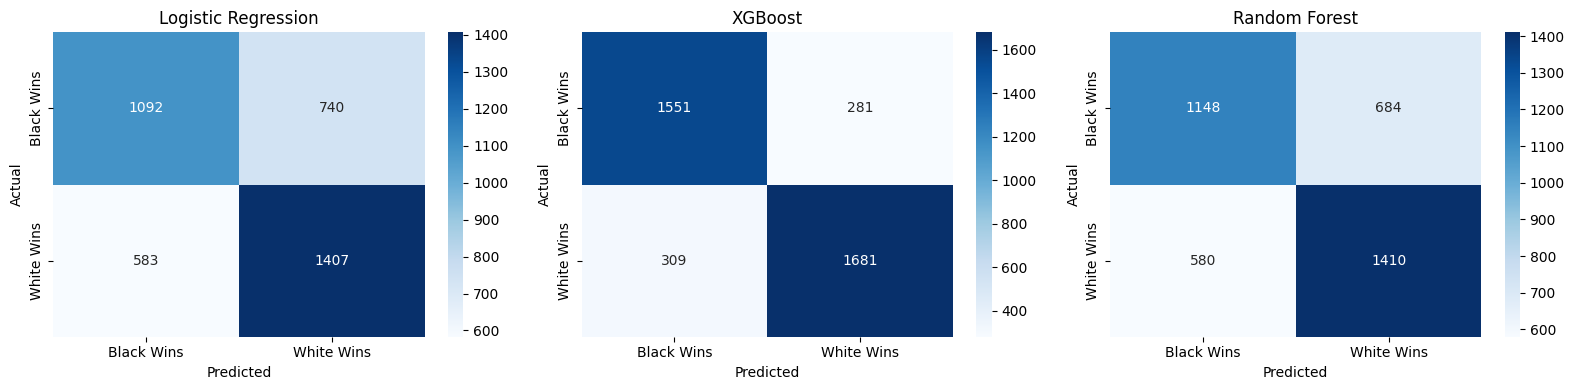

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, preds, title in zip(axes,
                             [y_pred_lr, y_pred_xgb, y_pred_rf],
                             ['Logistic Regression', 'XGBoost', 'Random Forest']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Black Wins', 'White Wins'],
                yticklabels=['Black Wins', 'White Wins'])
    ax.set_title(title)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

## 10. Feature Importance - XGBoost

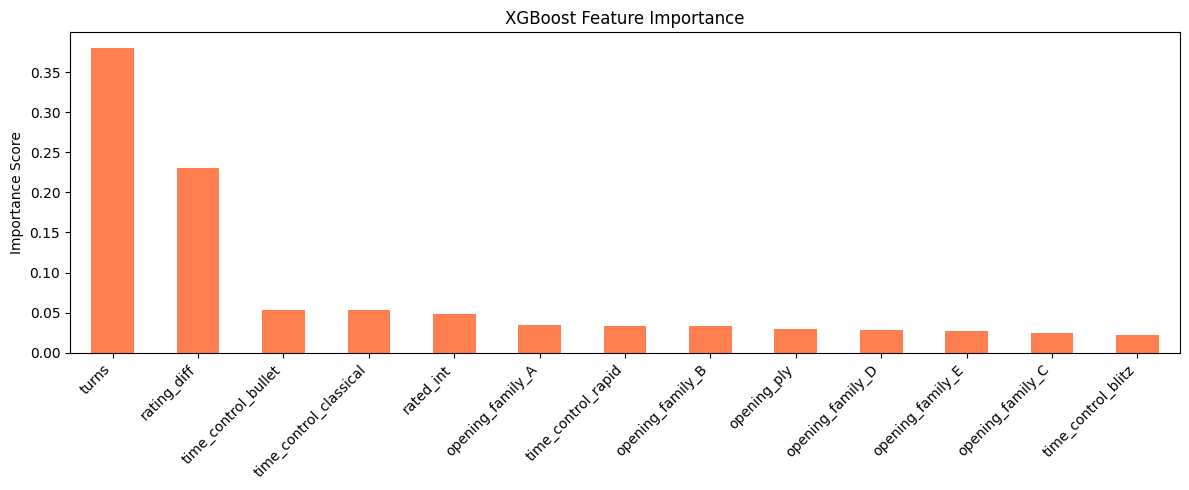

In [16]:
feat_importance = pd.Series(xgb.feature_importances_, index=X.columns)
feat_importance.sort_values(ascending=False).head(15).plot(kind='bar',
                                                            figsize=(12,5),
                                                            color='coral')
plt.title('XGBoost Feature Importance')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 12. SHAP Analysis

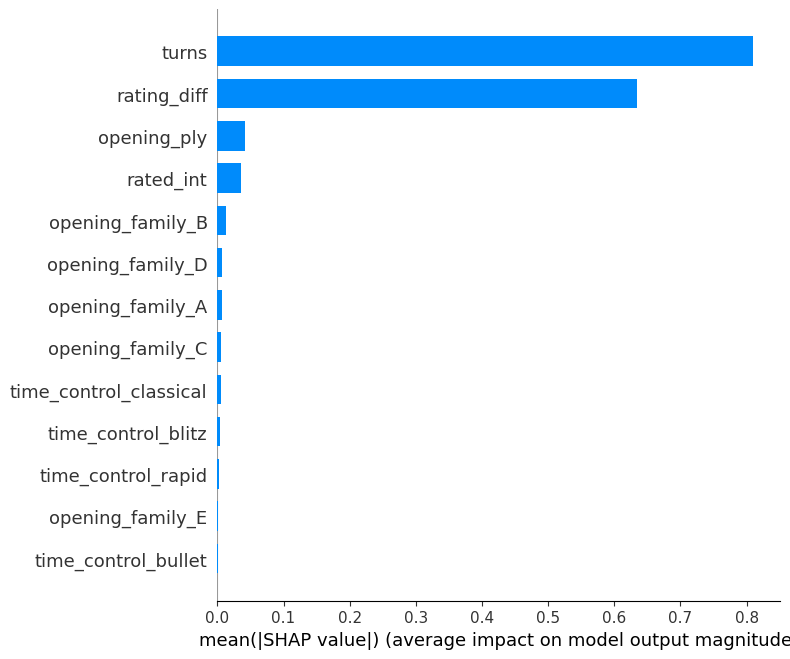

In [17]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, plot_type='bar', show=True)

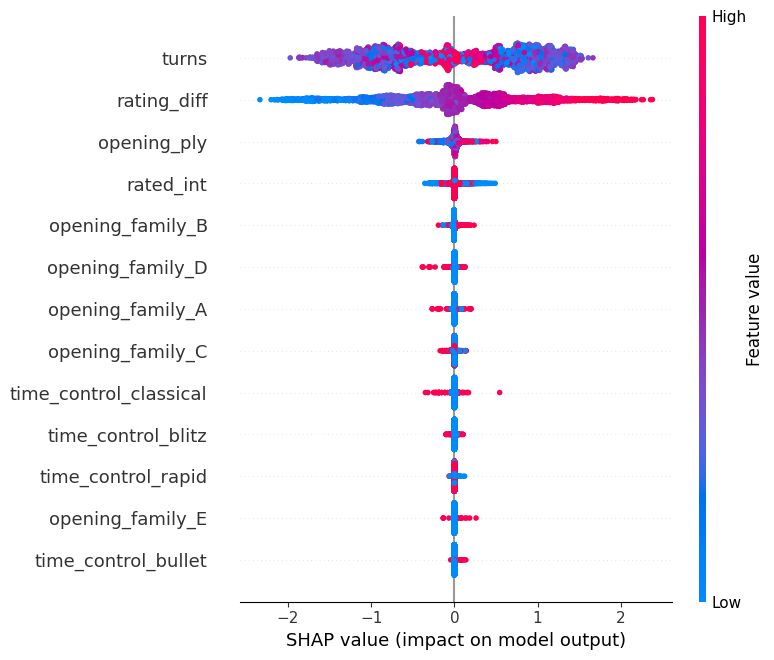

In [18]:
shap.summary_plot(shap_values, X_test, show=True)

## 12. Opening Family Analysis

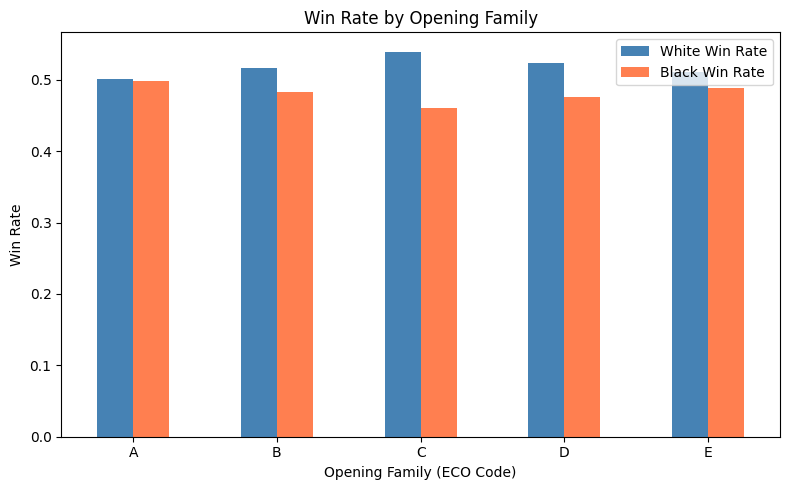

In [19]:
# Win rate by opening family
opening_wins = df_model.groupby(['opening_family', 'winner']).size().unstack(fill_value=0)
opening_wins['total'] = opening_wins.sum(axis=1)
opening_wins['white_winrate'] = opening_wins['white'] / opening_wins['total']
opening_wins['black_winrate'] = opening_wins['black'] / opening_wins['total']

opening_wins[['white_winrate', 'black_winrate']].plot(kind='bar',
                                                       figsize=(8,5),
                                                       color=['steelblue', 'coral'])
plt.title('Win Rate by Opening Family')
plt.ylabel('Win Rate')
plt.xlabel('Opening Family (ECO Code)')
plt.xticks(rotation=0)
plt.legend(['White Win Rate', 'Black Win Rate'])
plt.tight_layout()
plt.show()

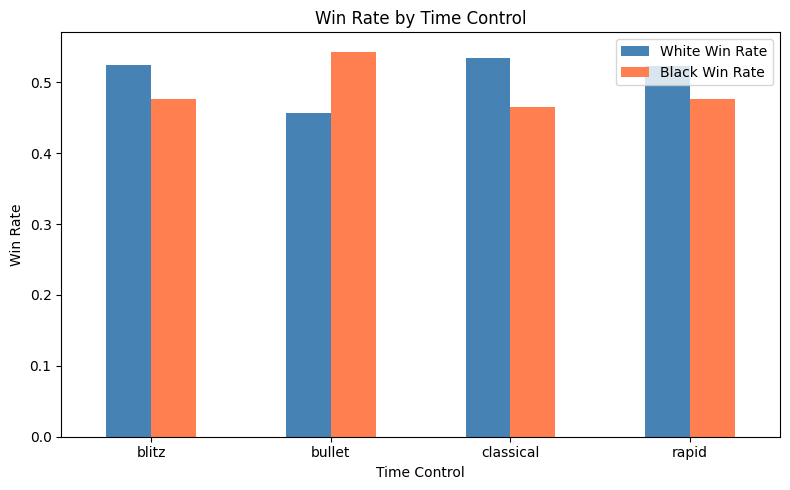

In [20]:
# Win rate by time control
tc_wins = df_model.groupby(['time_control', 'winner']).size().unstack(fill_value=0)
tc_wins['total'] = tc_wins.sum(axis=1)
tc_wins['white_winrate'] = tc_wins['white'] / tc_wins['total']
tc_wins['black_winrate'] = tc_wins['black'] / tc_wins['total']

tc_wins[['white_winrate', 'black_winrate']].plot(kind='bar',
                                                   figsize=(8,5),
                                                   color=['steelblue', 'coral'])
plt.title('Win Rate by Time Control')
plt.ylabel('Win Rate')
plt.xlabel('Time Control')
plt.xticks(rotation=0)
plt.legend(['White Win Rate', 'Black Win Rate'])
plt.tight_layout()
plt.show()

## 13. ROC Curves

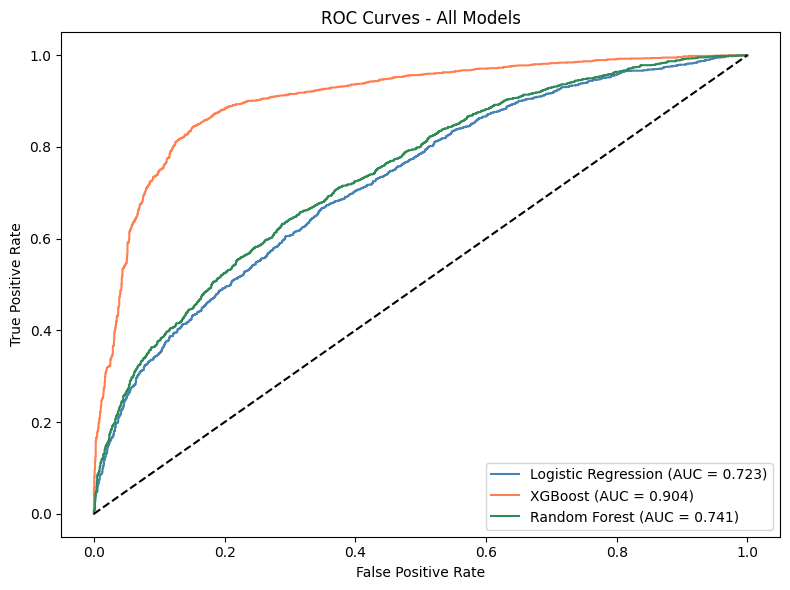

In [21]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

for preds_proba, label, color in [
    (lr.predict_proba(X_test)[:,1], 'Logistic Regression', 'steelblue'),
    (xgb.predict_proba(X_test)[:,1], 'XGBoost', 'coral'),
    (rf.predict_proba(X_test)[:,1], 'Random Forest', 'seagreen')
]:
    fpr, tpr, _ = roc_curve(y_test, preds_proba)
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{label} (AUC = {auc_score:.3f})', color=color)

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend()
plt.tight_layout()
plt.show()

## 14. Multiclass Classification (Including Draws)

In [22]:
from sklearn.preprocessing import LabelEncoder

# Use full dataset including draws
df_multi = df.copy()
le = LabelEncoder()
df_multi['target_multi'] = le.fit_transform(df_multi['winner'])
print("Classes:", le.classes_)

df_encoded_multi = pd.get_dummies(df_multi[['rating_diff', 'opening_ply',
                                             'rated_int', 'turns',
                                             'time_control', 'opening_family']])

X_multi = df_encoded_multi
y_multi = df_multi['target_multi']

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi,
                                                               test_size=0.2,
                                                               random_state=42)

xgb_multi = XGBClassifier(n_estimators=100, max_depth=6,
                            learning_rate=0.1, random_state=42,
                            eval_metric='mlogloss')
xgb_multi.fit(X_train_m, y_train_m)
y_pred_multi = xgb_multi.predict(X_test_m)

print("\n=== XGBoost Multiclass Results ===")
print(f"Accuracy: {accuracy_score(y_test_m, y_pred_multi):.4f}")
print()
print(classification_report(y_test_m, y_pred_multi, target_names=le.classes_))

Classes: ['black' 'draw' 'white']

=== XGBoost Multiclass Results ===
Accuracy: 0.7984

              precision    recall  f1-score   support

       black       0.80      0.81      0.81      1816
        draw       0.25      0.02      0.03       192
       white       0.80      0.86      0.83      2004

    accuracy                           0.80      4012
   macro avg       0.62      0.56      0.55      4012
weighted avg       0.77      0.80      0.78      4012



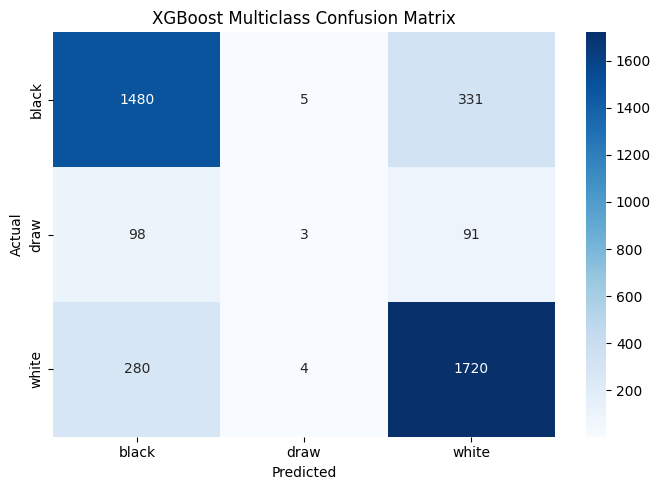

In [23]:
# Confusion matrix for multiclass
plt.figure(figsize=(7,5))
cm_multi = confusion_matrix(y_test_m, y_pred_multi)
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('XGBoost Multiclass Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## 15. Multiclass - All Models with Draws


In [24]:
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression Multiclass
lr_multi = LogisticRegression(max_iter=1000, random_state=42)
lr_multi.fit(X_train_m, y_train_m)
y_pred_lr_multi = lr_multi.predict(X_test_m)

# Random Forest Multiclass
rf_multi = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_multi.fit(X_train_m, y_train_m)
y_pred_rf_multi = rf_multi.predict(X_test_m)

print("=== Logistic Regression Multiclass ===")
print(f"Accuracy: {accuracy_score(y_test_m, y_pred_lr_multi):.4f}")
print(classification_report(y_test_m, y_pred_lr_multi, target_names=le.classes_))

print("=== Random Forest Multiclass ===")
print(f"Accuracy: {accuracy_score(y_test_m, y_pred_rf_multi):.4f}")
print(classification_report(y_test_m, y_pred_rf_multi, target_names=le.classes_))

=== Logistic Regression Multiclass ===
Accuracy: 0.6284
              precision    recall  f1-score   support

       black       0.62      0.58      0.60      1816
        draw       1.00      0.02      0.03       192
       white       0.63      0.73      0.68      2004

    accuracy                           0.63      4012
   macro avg       0.75      0.44      0.44      4012
weighted avg       0.65      0.63      0.61      4012

=== Random Forest Multiclass ===
Accuracy: 0.6373
              precision    recall  f1-score   support

       black       0.63      0.61      0.62      1816
        draw       0.67      0.01      0.02       192
       white       0.65      0.72      0.68      2004

    accuracy                           0.64      4012
   macro avg       0.65      0.45      0.44      4012
weighted avg       0.64      0.64      0.62      4012



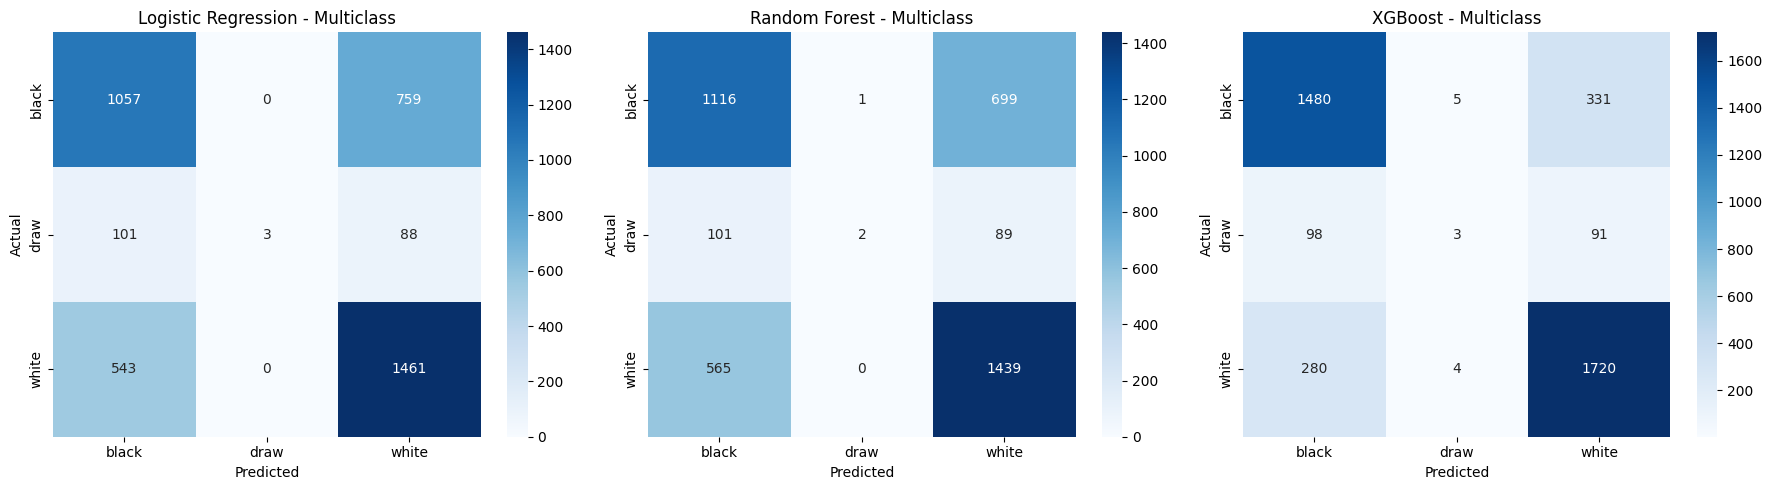

In [25]:
# Confusion matrices all 3 multiclass models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, preds, title in zip(axes,
                             [y_pred_lr_multi, y_pred_rf_multi, y_pred_multi],
                             ['Logistic Regression', 'Random Forest', 'XGBoost']):
    cm = confusion_matrix(y_test_m, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le.classes_,
                yticklabels=le.classes_)
    ax.set_title(f'{title} - Multiclass')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

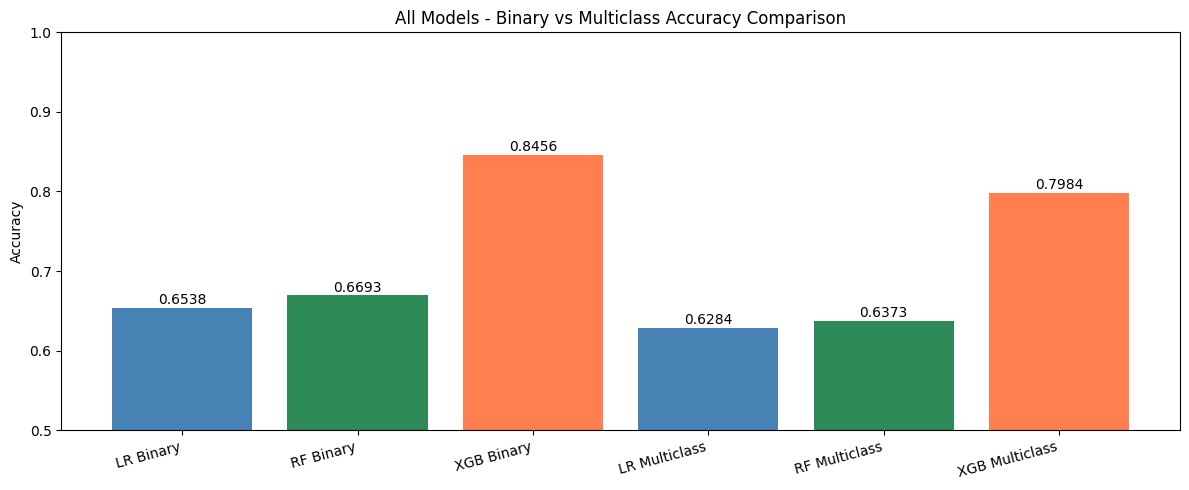

In [26]:
# Final accuracy comparison - all models all tasks
models_all = ['LR Binary', 'RF Binary', 'XGB Binary',
              'LR Multiclass', 'RF Multiclass', 'XGB Multiclass']
accs_all = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_xgb),
    accuracy_score(y_test_m, y_pred_lr_multi),
    accuracy_score(y_test_m, y_pred_rf_multi),
    accuracy_score(y_test_m, y_pred_multi)
]

colors = ['steelblue', 'seagreen', 'coral', 'steelblue', 'seagreen', 'coral']

plt.figure(figsize=(12, 5))
bars = plt.bar(models_all, accs_all, color=colors)
plt.ylim(0.5, 1.0)
plt.title('All Models - Binary vs Multiclass Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=15, ha='right')
for bar, acc in zip(bars, accs_all):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.4f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()